# 🏥 Medical Insurance Cost Prediction using Linear Regression

## 📊 Dataset

### Features

| Feature | Description |

|----------|-------------|

| Age | Age of the insured person |

| Sex | Male or Female |

| BMI | Body Mass Index |

| Children | Number of dependents covered |

| Smoker | Smoking status (Yes/No) |

| Region | Residential region |

| Charges | Medical insurance cost (Target Variable) 

## 📌 Project Overview

This project uses **Machine Learning** to predict individual medical insurance charges based on personal and demographic information. The model is built using **Linear Regression** and follows a complete data science workflow, from data exploration to model evaluation.

The dataset contains information about customers such as age, gender, BMI, number of children, smoking status, region, and their medical insurance charges.

---

## 🎯 Project Objectives

- Perform Exploratory Data Analysis (EDA)

- Clean and preprocess the data

- Encode categorical variables

- Train a Linear Regression model

- Evaluate the model using regression metrics

- Understand which factors have the greatest impact on insurance costs

# Import the necessary libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data

In [2]:
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# checking the data and do some exploratory data analysis

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


### See the relationships between charges and other features

In [4]:
df.corr(numeric_only=True)

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


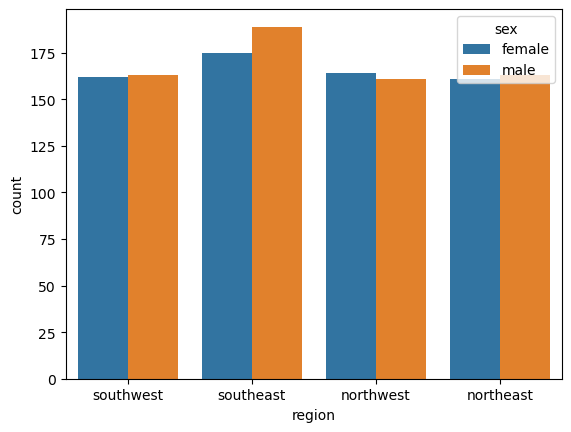

In [6]:
sns.countplot(df, x='region', hue='sex');

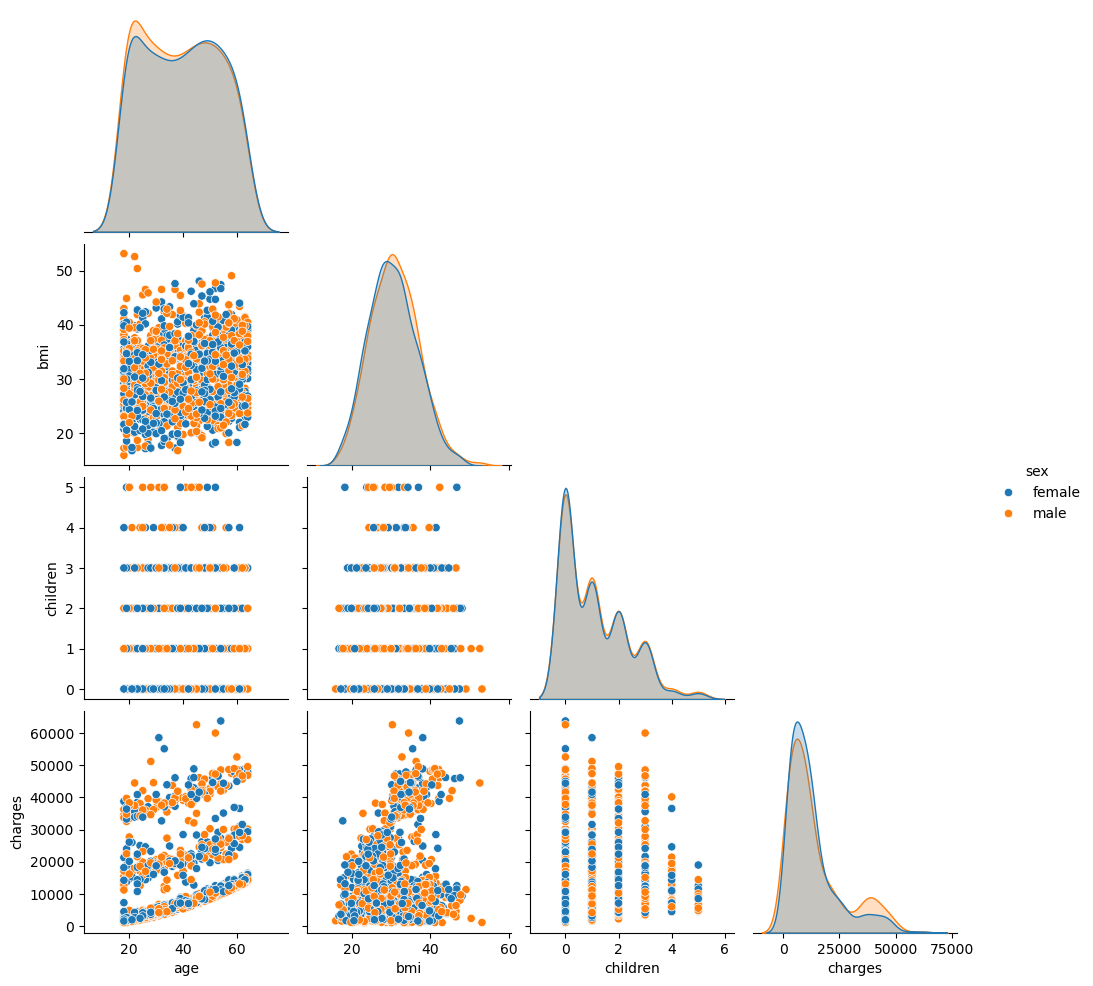

In [8]:
sns.pairplot(df, hue='sex', corner=True);

In [9]:
df['sex'].value_counts()

sex
male      676
female    662
Name: count, dtype: int64

In [10]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

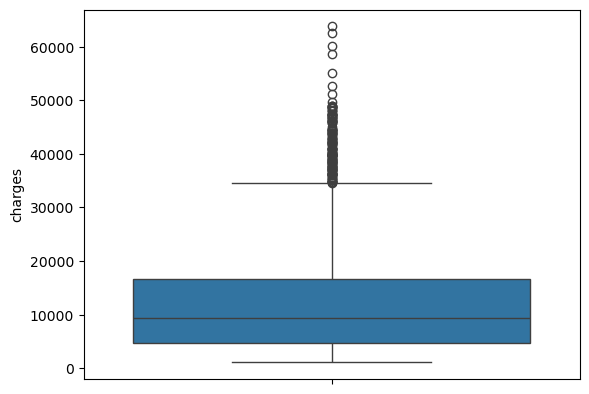

In [12]:
sns.boxplot(df['charges']);

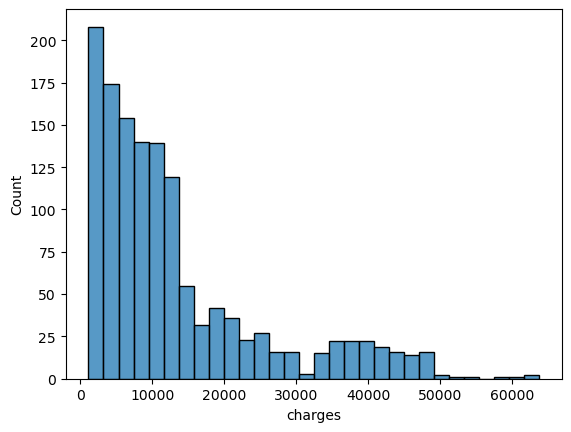

In [14]:
sns.histplot(df['charges']);

In [15]:
df['charges'].describe()

count     1338.000000
mean     13270.422265
std      12110.011237
min       1121.873900
25%       4740.287150
50%       9382.033000
75%      16639.912515
max      63770.428010
Name: charges, dtype: float64

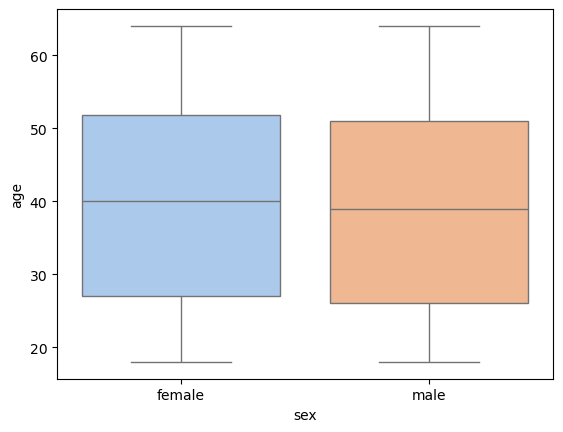

In [20]:
sns.boxplot(df, x='sex', y='age', palette='pastel', hue='sex');

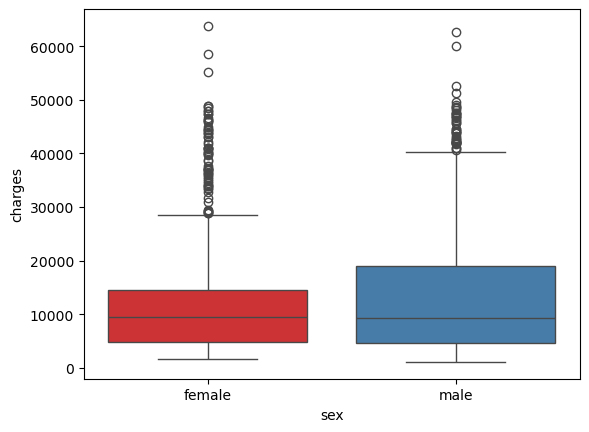

In [23]:
sns.boxplot(df, x='sex', y='charges', hue='sex', palette='Set1');

# Now we go through data prepration 

In [24]:
df = pd.get_dummies(df, columns=['sex','region','smoker'], dtype=int)
df.head()

,age,bmi,children,charges,sex_female,sex_male,region_northeast,region_northwest,region_southeast,region_southwest,smoker_no,smoker_yes
0,19,27.900,0,16884.92400,1,0,0,0,0,1,0,1
1,18,33.770,1,1725.55230,0,1,0,0,1,0,1,0
2,28,33.000,3,4449.46200,0,1,0,0,1,0,1,0
3,33,22.705,0,21984.47061,0,1,0,1,0,0,1,0
4,32,28.880,0,3866.85520,0,1,0,1,0,0,1,0


In [25]:
X = df.drop('charges', axis=1)
y = df['charges']

### The last step we do the ML process to find the best coefs and deploy it in real unseen data

In [26]:
from sklearn.model_selection import train_test_split

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [28]:
from sklearn.linear_model import LinearRegression

In [29]:
model = LinearRegression()

In [30]:
model.fit(X_train, y_train)

LinearRegression()

In [31]:
y_prediction = model.predict(X_test)

In [32]:
from sklearn.metrics import r2_score, mean_absolute_error,mean_squared_error

In [37]:
mae = mean_absolute_error(y_test, y_prediction)
rmse = np.sqrt(mean_squared_error(y_test, y_prediction))
r_2 = r2_score(y_test, y_prediction)

print(f'Mean absolute error: {mae}')
print(f'Root mean squared error: {rmse}')
print(f'R^2 : {r_2}')

Mean absolute error: 4145.450555627585
Root mean squared error: 5812.100272258869
R^2 : 0.7696118054369012


#### The model is pretty good but we can work more on it and we should
#### remember that some unseen features are not involved such as previous disease and ...

In [38]:
final_model = LinearRegression()

In [39]:
final_model.fit(X,y)

LinearRegression()

In [40]:
final_model.coef_

array([   256.85635254,    339.19345361,    475.50054515,     65.6571797 ,
          -65.6571797 ,    587.00923503,    234.0453356 ,   -448.01281436,
         -373.04175627, -11924.26727096,  11924.26727096])

In [41]:
from joblib import dump,load

In [43]:
dump(final_model, 'insurance_cost_prediction.joblib')

['insurance_cost_prediction.joblib']

In [44]:
load_model = load('insurance_cost_prediction.joblib')

In [45]:
load_model.coef_

array([   256.85635254,    339.19345361,    475.50054515,     65.6571797 ,
          -65.6571797 ,    587.00923503,    234.0453356 ,   -448.01281436,
         -373.04175627, -11924.26727096,  11924.26727096])

In [52]:
new_customer = [[20,25,5,0,1,0,0,1,0,0,1]]

In [53]:
load_model.predict(new_customer)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([26738.12567373])

# Finish